# LeetCode #21: Merge Two Sorted Lists

https://leetcode.com/problems/merge-two-sorted-lists/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O((m+n)\log(m+n))$ | $O(m+n)$ |
| **Iterative Dummy Head** ★ | $O(m+n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Traverse both lists and collect every node value into an auxiliary array, sort it in $O((m+n)\log(m+n))$, then rebuild a new linked list. Correct but wasteful: it allocates $O(m+n)$ extra memory and pays a log factor for sorting values that are already mostly sorted.

### Optimal: Iterative Dummy Head ★
Create a sentinel (dummy) node whose `.next` will become the merged head. Keep a `current` pointer starting at dummy. At each step compare the heads of the two remaining sublists, append the smaller node to `current.next`, advance that sublist's pointer, and move `current` forward. When one list is exhausted, splice the remaining tail in one $O(1)$ pointer assignment. Return `dummy.next`.

**Why this is better than Brute Force:** Single linear scan with $O(1)$ work per node; no auxiliary array, no sort, no list reconstruction — only pointer rewiring on the original nodes.

**Constraints:**
* The number of nodes in both lists is in the range $[0, 50]$
* $-100 \leq \text{Node.val} \leq 100$
* Both `list1` and `list2` are sorted in non-decreasing order

## Solutions

### C#

In [ ]:
public class ListNode {
    public int val;
    public ListNode next;
    public ListNode(int val = 0, ListNode next = null) {
        this.val = val;
        this.next = next;
    }
}

public class Solution {
    public ListNode MergeTwoLists(ListNode list1, ListNode list2) {
        ListNode dummy = new ListNode(0);
        ListNode current = dummy;

        while (list1 != null && list2 != null) {
            if (list1.val <= list2.val) {
                current.next = list1;
                list1 = list1.next;
            } else {
                current.next = list2;
                list2 = list2.next;
            }
            current = current.next;
        }

        // Attach the remaining non-null tail — O(1)
        current.next = list1 ?? list2;
        return dummy.next;
    }
}

### Python

In [ ]:
from typing import Optional

class ListNode:
    def __init__(self, val: int = 0, next: "Optional[ListNode]" = None):
        self.val = val
        self.next = next

class Solution:
    def mergeTwoLists(
        self,
        list1: Optional[ListNode],
        list2: Optional[ListNode],
    ) -> Optional[ListNode]:
        dummy = ListNode(0)
        current = dummy

        while list1 and list2:
            if list1.val <= list2.val:
                current.next = list1
                list1 = list1.next
            else:
                current.next = list2
                list2 = list2.next
            current = current.next

        # Splice remaining tail — O(1)
        current.next = list1 or list2
        return dummy.next

### Go

In [ ]:
type ListNode struct {
    Val  int
    Next *ListNode
}

func mergeTwoLists(list1 *ListNode, list2 *ListNode) *ListNode {
    dummy := &ListNode{}
    current := dummy

    for list1 != nil && list2 != nil {
        if list1.Val <= list2.Val {
            current.Next = list1
            list1 = list1.Next
        } else {
            current.Next = list2
            list2 = list2.Next
        }
        current = current.Next
    }

    // Attach remaining tail — O(1)
    if list1 != nil {
        current.Next = list1
    } else {
        current.Next = list2
    }

    return dummy.Next
}

### Rust

In [ ]:
#[derive(PartialEq, Eq, Clone, Debug)]
pub struct ListNode {
    pub val: i32,
    pub next: Option<Box<ListNode>>,
}

impl ListNode {
    #[inline]
    fn new(val: i32) -> Self {
        ListNode { val, next: None }
    }
}

pub fn merge_two_lists(
    mut list1: Option<Box<ListNode>>,
    mut list2: Option<Box<ListNode>>,
) -> Option<Box<ListNode>> {
    let mut dummy = Box::new(ListNode::new(0));
    let mut current = &mut dummy;

    while list1.is_some() && list2.is_some() {
        if list1.as_ref().unwrap().val <= list2.as_ref().unwrap().val {
            current.next = list1.take();
            current = current.next.as_mut().unwrap();
            list1 = current.next.take();
        } else {
            current.next = list2.take();
            current = current.next.as_mut().unwrap();
            list2 = current.next.take();
        }
    }

    // Splice remaining tail — O(1)
    current.next = if list1.is_some() { list1 } else { list2 };
    dummy.next
}

## Example Scenarios

**1. Common Case**
**Input:** list1 = [1, 2, 4], list2 = [1, 3, 4]
Compare heads each step: 1≤1 → take list1's 1; 2>1 → take list2's 1; 2≤3 → take list1's 2; 3≤4? No, 3<4 → take list2's 3; 4≤4 → take list1's 4; list1 exhausted → splice list2's 4. Output: [1, 1, 2, 3, 4, 4]. Total iterations = m + n = 3 + 3 = 6.

**2. Slightly Complex — one list exhausted early**
**Input:** list1 = [1, 3], list2 = [2, 4, 5, 6]
After 2 comparisons list1 is exhausted. The remaining tail [4, 5, 6] is spliced with a single pointer assignment current.next = list2. No extra traversal needed — this is the O(1) tail-splice advantage of the dummy-head pattern. Output: [1, 2, 3, 4, 5, 6].

**3. Edge Case: Time Factor — fully interleaved equal-length lists**
**Input:** list1 = [1, 3, 5, … , 2k−1], list2 = [2, 4, 6, … , 2k]
Every comparison produces a winner from an alternating list, so the while-loop runs exactly m + n − 1 = 2k − 1 times before the last element of list2 is spliced as the tail. No early exit is possible. This is the worst-case scenario for the number of comparisons performed, reaching the full O(m + n) bound.

**4. Edge Case: Space Factor — one list is null**
**Input:** list1 = null, list2 = [1, 2, 3]
The while-loop condition fails immediately (list1 == null). current.next = list1 ?? list2 = list2. dummy.next = list2's head. Returns list2 unmodified. Space used = O(1) regardless of n — no auxiliary structures are allocated even for a 50-node list2.

**5. Almost-Impossible but Plausible — both lists null**
**Input:** list1 = null, list2 = null
Allowed by the constraint: number of nodes ∈ [0, 50]. The while-loop never executes. current.next = null ?? null = null. dummy.next = null. Returns null — the correct representation of an empty merged list — in O(1) time with zero iterations and zero allocations. The iterative dummy-head pattern handles this correctly with no special-casing required.

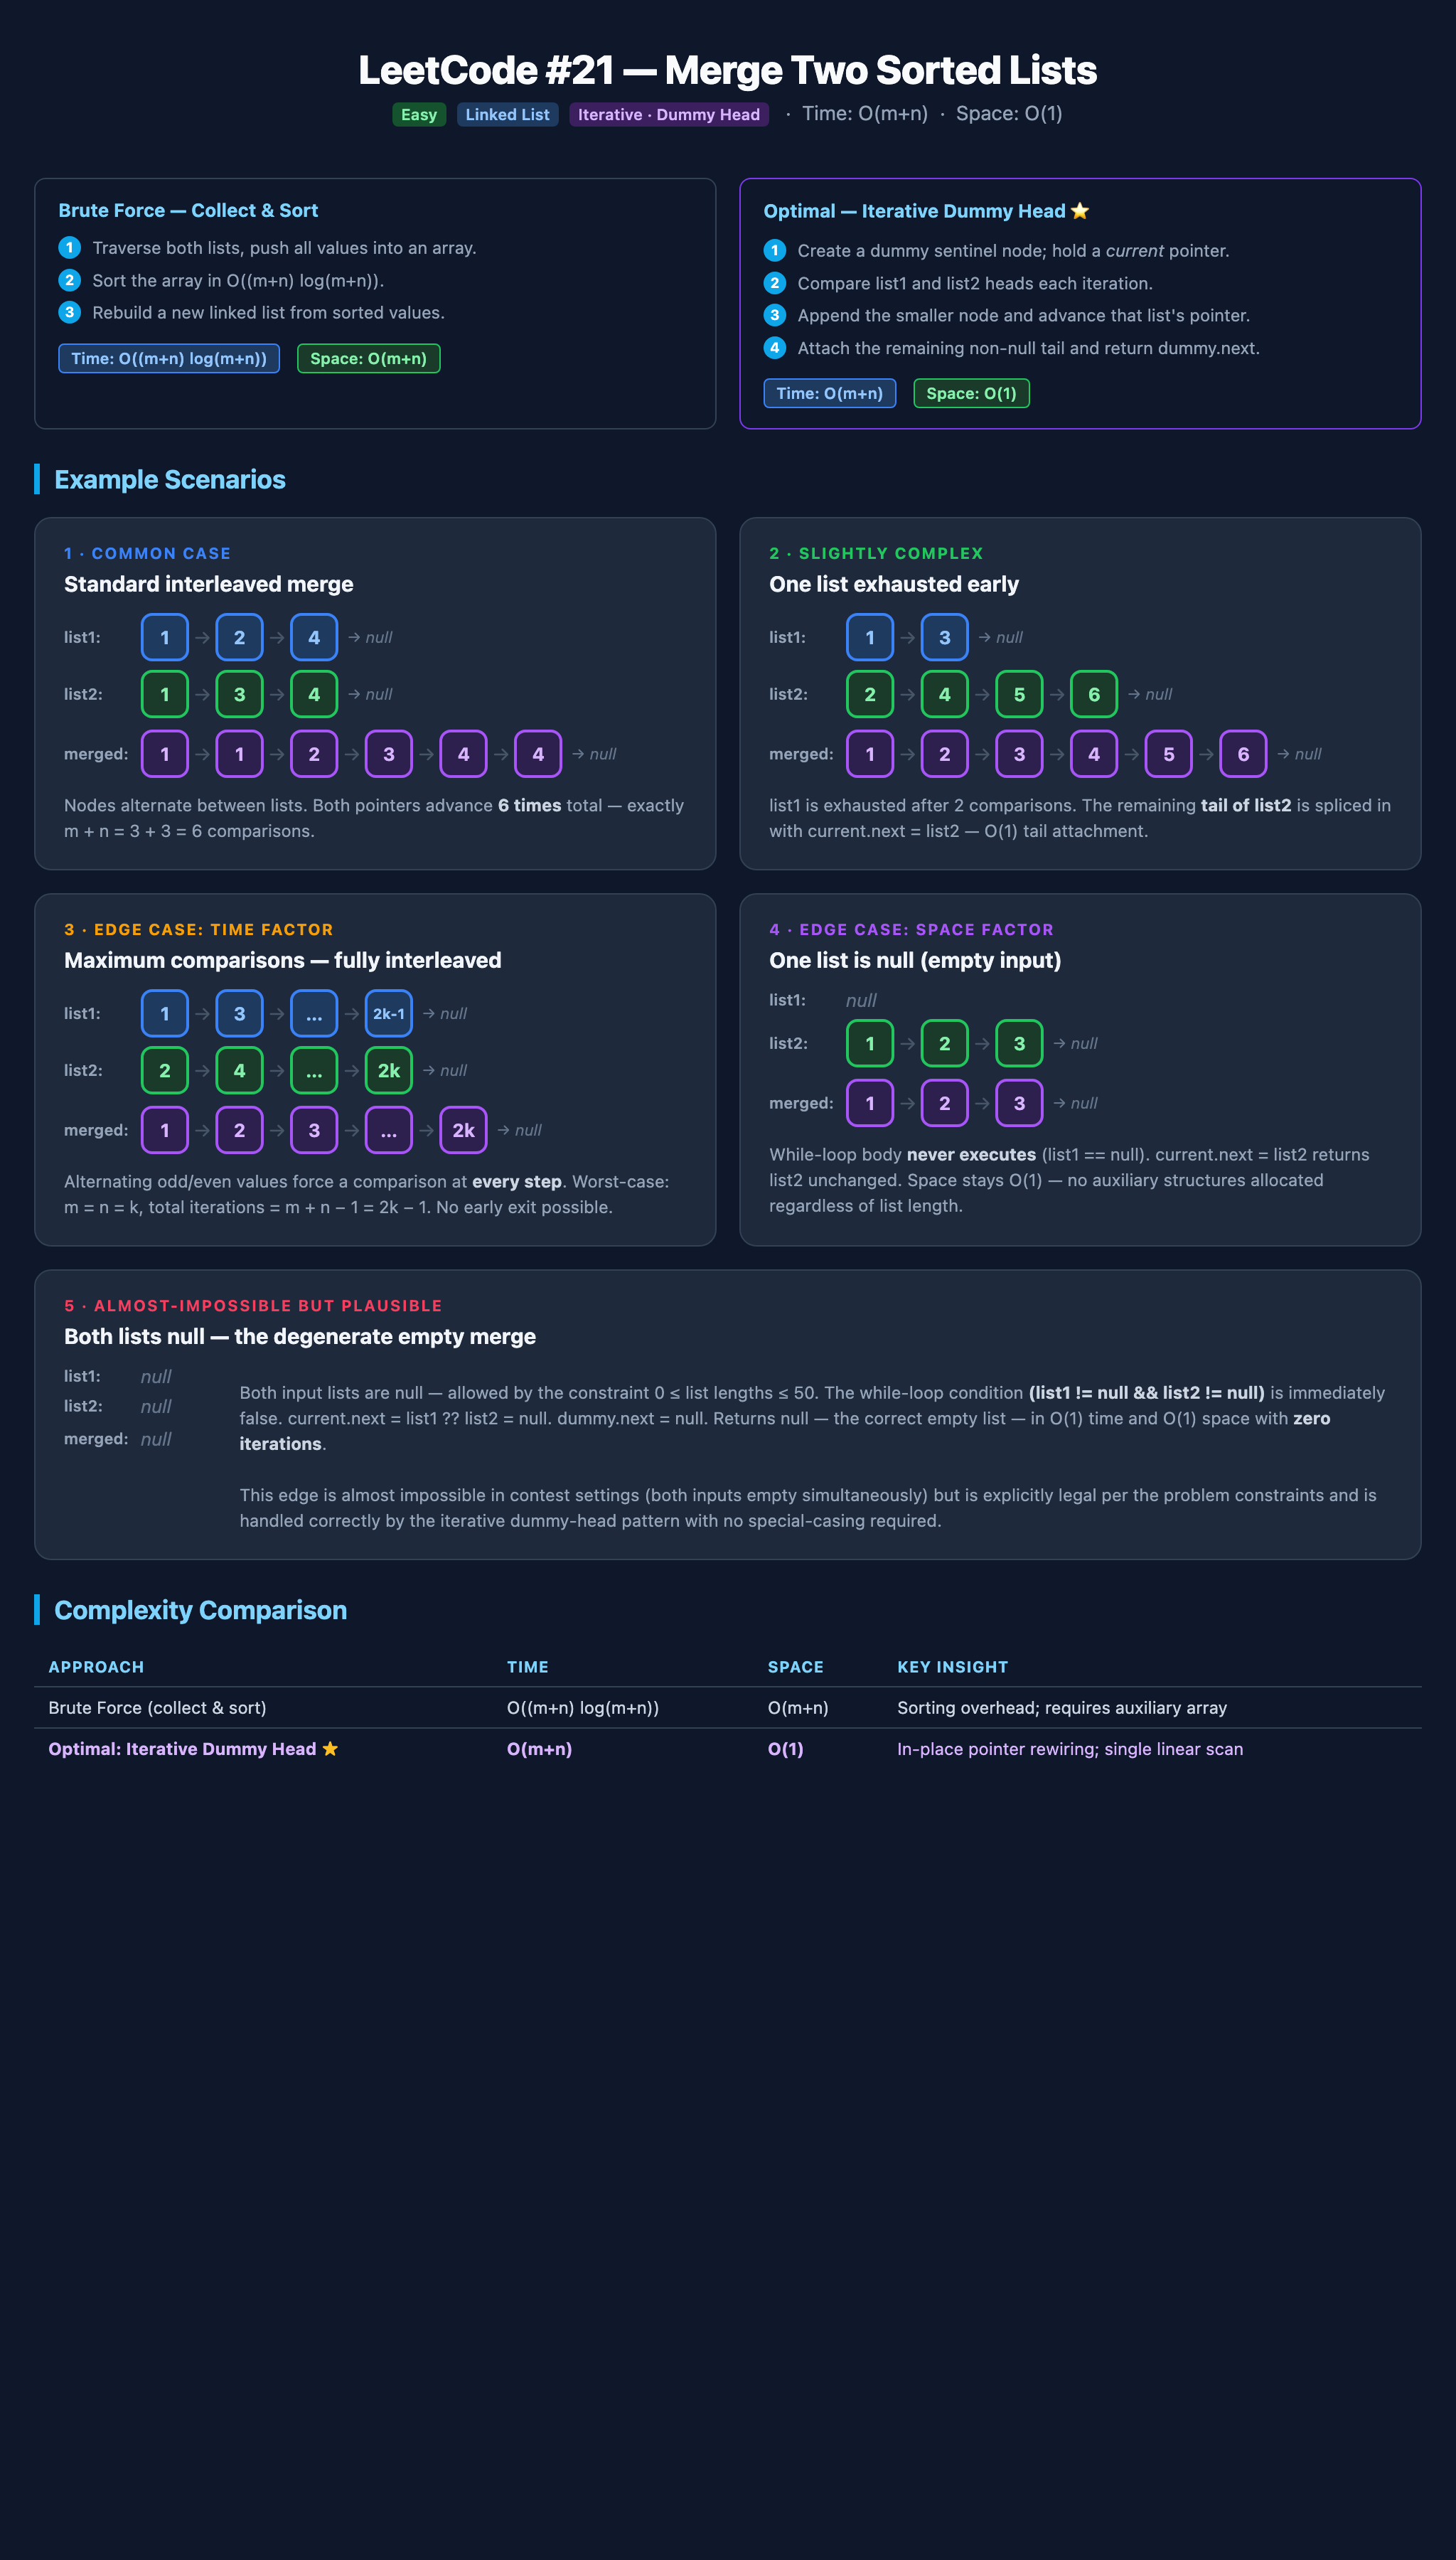